WEEK 1 — Data Collection, Text Cleaning & EDA

Generate a Synthetic Dataset


In [1]:
# week1_eda.ipynb — Cell 1: Generate Dataset
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

departments = ['Water', 'Electricity', 'Roads', 'Sanitation', 'Transport', 'Healthcare']
sentiments  = ['Positive', 'Neutral', 'Negative', 'Critical/Urgent']

templates = {
    'Water': [
        "There is no water supply in our area since {n} days. Please fix urgently.",
        "Water pipeline is broken near {loc} and flooding the street.",
        "Low water pressure in {loc} for the past week.",
        "Dirty water coming from taps in {loc} colony.",
    ],
    'Electricity': [
        "Power cuts happening every day for {n} hours in {loc}.",
        "Electric pole is damaged and sparking near {loc} market.",
        "No electricity since {n} days in {loc} area.",
        "Street lights not working in {loc} for a month.",
    ],
    'Roads': [
        "There are huge potholes on the {loc} main road causing accidents.",
        "Road construction debris not cleared in {loc} for {n} weeks.",
        "The bridge near {loc} is in very bad condition.",
        "Speed breakers broken on {loc} highway.",
    ],
    'Sanitation': [
        "Garbage not collected in {loc} for {n} days. Very bad smell.",
        "Sewage overflow on {loc} street is a health hazard.",
        "Public toilet near {loc} is completely broken and unusable.",
        "Drainage blocked in {loc} causing flooding every rain.",
    ],
    'Transport': [
        "Bus route {n} is not running on time in {loc}.",
        "No bus shelter at {loc} stop. Commuters standing in rain.",
        "Auto drivers in {loc} charging excess fare.",
        "Traffic signal broken at {loc} junction causing daily jams.",
    ],
    'Healthcare': [
        "Government hospital in {loc} has no doctors available.",
        "Medicines out of stock at {loc} PHC for {n} days.",
        "Ambulance service not responding in {loc} area.",
        "Vaccination camp cancelled in {loc} without any notice.",
    ],
}

sentiment_map = {
    'Water':       ['Negative', 'Critical/Urgent', 'Negative', 'Negative'],
    'Electricity': ['Negative', 'Critical/Urgent', 'Critical/Urgent', 'Neutral'],
    'Roads':       ['Negative', 'Neutral', 'Critical/Urgent', 'Neutral'],
    'Sanitation':  ['Negative', 'Critical/Urgent', 'Negative', 'Negative'],
    'Transport':   ['Neutral', 'Negative', 'Negative', 'Negative'],
    'Healthcare':  ['Critical/Urgent', 'Negative', 'Critical/Urgent', 'Negative'],
}

locations = ['Koramangala', 'Whitefield', 'Banjara Hills', 'Ameerpet',
             'Hitech City', 'Madhapur', 'Gachibowli', 'LB Nagar']

rows = []
for _ in range(1000):
    dept = random.choice(departments)
    idx  = random.randint(0, len(templates[dept]) - 1)
    text = templates[dept][idx].format(
        n=random.randint(1, 15),
        loc=random.choice(locations)
    )
    sentiment = sentiment_map[dept][idx]
    rows.append({'text': text, 'department': dept, 'sentiment': sentiment})

df = pd.DataFrame(rows)
df.to_csv('../data/grievances.csv', index=False)
print(df.shape)
df.head(10)

(1000, 3)


,text,department,sentiment
0,Government hospital in Hitech City has no doct...,Healthcare,Critical/Urgent
1,Electric pole is damaged and sparking near Whi...,Electricity,Critical/Urgent
2,Government hospital in Gachibowli has no docto...,Healthcare,Critical/Urgent
3,There is no water supply in our area since 2 d...,Water,Negative
4,Power cuts happening every day for 9 hours in ...,Electricity,Negative
5,Vaccination camp cancelled in LB Nagar without...,Healthcare,Negative
6,Auto drivers in Koramangala charging excess fare.,Transport,Negative
7,Street lights not working in Hitech City for a...,Electricity,Neutral
8,Electric pole is damaged and sparking near Mad...,Electricity,Critical/Urgent
9,There is no water supply in our area since 7 d...,Water,Negative


Text Preprocessing

In [2]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 2: Install & import
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)             # remove special chars/numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(5)

[nltk_data] Downloading package stopwords to C:\Users\Chenna
[nltk_data]     Keshava\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Chenna
[nltk_data]     Keshava\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Chenna
[nltk_data]     Keshava\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,clean_text
0,Government hospital in Hitech City has no doct...,government hospital hitech city doctor available
1,Electric pole is damaged and sparking near Whi...,electric pole damaged sparking near whitefield...
2,Government hospital in Gachibowli has no docto...,government hospital gachibowli doctor available
3,There is no water supply in our area since 2 d...,water supply area since day please fix urgently
4,Power cuts happening every day for 9 hours in ...,power cut happening every day hour ameerpet


EDA — Class Distribution, Word Cloud, N-grams

Department & Sentiment distribution

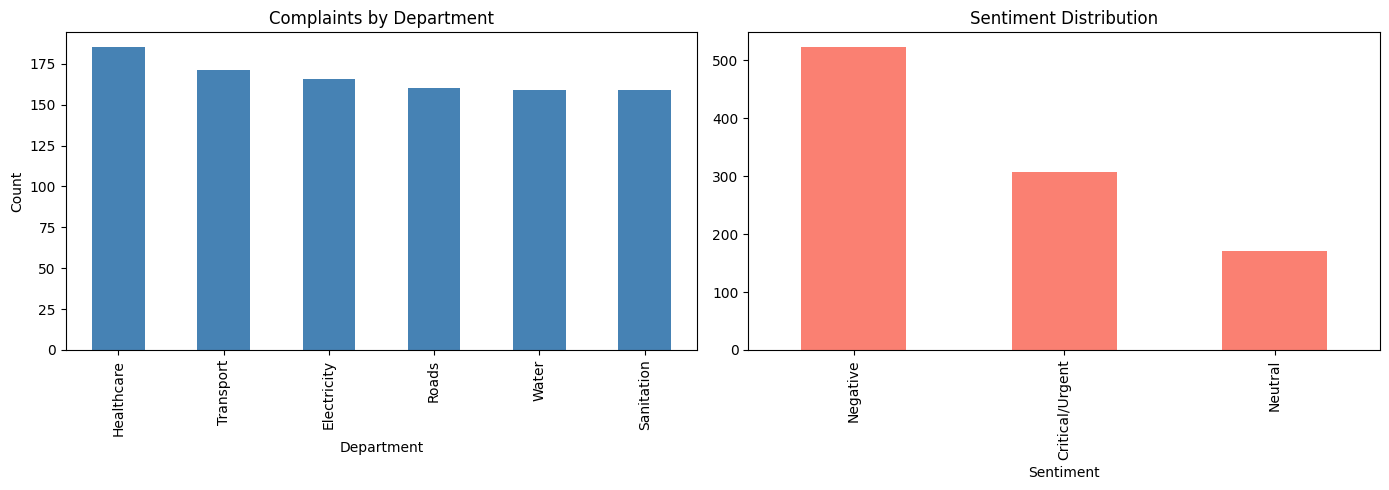

In [4]:
# Cell 3: Department & Sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['department'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Complaints by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')

df['sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Sentiment Distribution')
axes[1].set_xlabel('Sentiment')

plt.tight_layout()
plt.savefig('../data/distribution.png')
plt.show()

Word Cloud

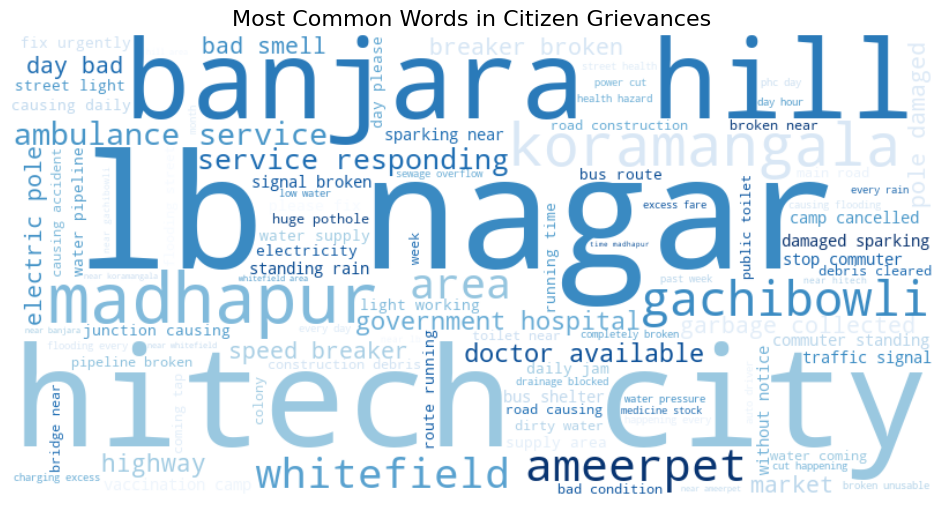

In [5]:
# Cell 4: Word Cloud
from wordcloud import WordCloud

all_text = ' '.join(df['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Blues', max_words=100).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Citizen Grievances', fontsize=16)
plt.savefig('../data/wordcloud.png')
plt.show()

Bigram (2-gram) Frequency

C:\Users\Chenna Keshava\AppData\Local\Temp\ipykernel_4772\3441099105.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette='viridis')


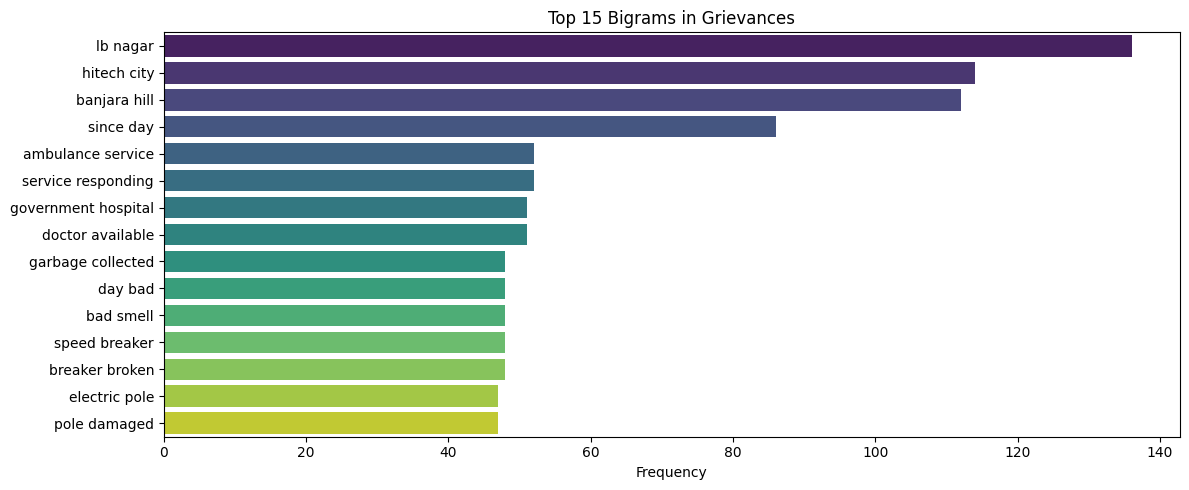

In [6]:
# Cell 5: Bigram (2-gram) Frequency
from collections import Counter
from nltk.util import ngrams

all_tokens = ' '.join(df['clean_text']).split()
bigrams    = list(ngrams(all_tokens, 2))
bigram_freq = Counter(bigrams).most_common(15)

labels  = [' '.join(b) for b, _ in bigram_freq]
counts  = [c for _, c in bigram_freq]

plt.figure(figsize=(12, 5))
sns.barplot(x=counts, y=labels, palette='viridis')
plt.title('Top 15 Bigrams in Grievances')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('../data/bigrams.png')
plt.show()